In [168]:
# Library setup and CSV Loader Extracted from GEE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)

import xgboost as xgb

RANDOM_STATE = 42
df = pd.read_csv('assets/rw_ciliwung_hilir_v5_relatif.csv')

print("Shape:", df.shape)
print("Relative columns:", [c for c in df.columns if "_rel_" in c])
display(df.head())

Shape: (365, 89)
Relative columns: ['dist_river_rel_max', 'dist_river_rel_mean', 'dist_river_rel_min', 'dist_river_rel_stdDev', 'elevation_rel_max', 'elevation_rel_mean', 'elevation_rel_min', 'elevation_rel_stdDev', 'hand_rel_max', 'hand_rel_mean', 'hand_rel_min', 'hand_rel_stdDev', 'slope_rel_max', 'slope_rel_mean', 'slope_rel_min', 'slope_rel_stdDev', 'twi_rel_max', 'twi_rel_mean', 'twi_rel_min', 'twi_rel_stdDev', 'upstream_area_rel_max', 'upstream_area_rel_mean', 'upstream_area_rel_min', 'upstream_area_rel_stdDev']


,system:index,Jumlah_KK_,KECAMATAN,KELURAHAN,KODE_KEL,KODE_RW,Kategori_B,Kel_dan_RW,Keterangan,Lama_Genan,...,upstream_area_rel_max,upstream_area_rel_mean,upstream_area_rel_min,upstream_area_rel_stdDev,upstream_area_stdDev,vegetasi_max,vegetasi_mean,vegetasi_min,vegetasi_stdDev,.geo
0,000000000000000002a0,138,SAWAH BESAR,PASAR BARU,3171021001,3.171021e+12,Rendah,Pasar Baru 05,Dibawah jalan kartini raya,12 Jam (setengah hari),...,-0.653713,-4.955647,-10.827956,2.059339,0.120942,1,0.009617,0,0.101010,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,00000000000000000255,240,SAWAH BESAR,MANGGA DUA SELATAN,3171021005,3.171021e+12,Rendah,Mangga Dua Selatan 01,-,5 Jam,...,-1.765171,-8.090895,-11.019469,2.220645,0.459899,1,0.134207,0,0.325451,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,00000000000000000258,80,SAWAH BESAR,MANGGA DUA SELATAN,3171021005,3.171021e+12,Rendah,Mangga Dua Selatan 04,Sudah dihubungi,1 - 2 Jam,...,-7.891072,-11.108074,-12.593612,1.525333,1.439524,0,0.000000,0,0.000000,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0000000000000000025c,150,SAWAH BESAR,MANGGA DUA SELATAN,3171021005,3.171021e+12,Rendah,Mangga Dua Selatan 10,-,1 Jam setelah hujan berhenti,...,0.664702,-1.096471,-5.816022,1.608431,0.167172,1,0.051443,0,0.211371,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0000000000000000002d,500,TANJUNG PRIOK,SUNTER AGUNG,3172021006,3.172021e+12,Rendah,Sunter Agung 10,NaN,NaN,...,105.906676,2.140376,-4.828990,31.034590,31.051911,1,0.029605,0,0.179185,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [169]:
#1. Label Mapping: From 5 Classes to 3 Classes
label_map = {
    "Sangat Rendah": 0,
    "Rendah": 0,
    "Sedang": 1,
    "Tinggi": 2,
    "Sangat Tinggi": 2
}

# Historical Data of Flood in DKI Jakarta 2010 - 2020
dilatih = df[df["Kategori_B"].isin(label_map.keys())].copy()
dilatih["target"] = dilatih["Kategori_B"].map(label_map)

print("Total Labeled Data", len(dilatih))
print("\nClass Distribution:")
print(dilatih["target"].value_counts().sort_index())

print("\nClass Percentages:")
print(
    (dilatih["target"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)


Total Labeled Data 182

Class Distribution:
target
0    34
1    62
2    86
Name: count, dtype: int64

Class Percentages:
target
0    18.68
1    34.07
2    47.25
Name: proportion, dtype: float64


In [170]:
#2. Feature Set: Absolute, Relative, and Combined
#Absolute
ABS_FEATURES = [
    "elevation_mean",
    "elevation_min",
    "hand_mean",
    "hand_min",
    "twi_mean",
    "dist_river_min",
    "slope_mean",
    "upstream_area_max",
    "builtup_mean",
    "vegetasi_mean",
    "VV_dry_mean",
    "VH_dry_mean"
]

#Relative
REL_FEATURES = [
    "elevation_rel_mean",
    "elevation_rel_min",
    "hand_rel_mean",
    "hand_rel_min",
    "twi_rel_mean",
    "dist_river_rel_min",
    "slope_rel_mean",
    "upstream_area_rel_max",
    "builtup_mean",
    "vegetasi_mean",
    "VV_dry_mean",
    "VH_dry_mean"
]

#Combined
COMBINED_FEATURES = [
    "elevation_mean",
    "elevation_min",
    "elevation_rel_mean",
    "elevation_rel_min",

    "hand_mean",
    "hand_min",
    "hand_rel_mean",
    "hand_rel_min",

    "twi_mean",
    "twi_rel_mean",

    "dist_river_min",
    "dist_river_rel_min",

    "slope_mean",
    "slope_rel_mean",

    "upstream_area_max",
    "upstream_area_rel_max",

    "builtup_mean",
    "vegetasi_mean",

    "VV_dry_mean",
    "VH_dry_mean"
]

FEATURE_SETS = {
    "Absolute": ABS_FEATURES,
    "Relative": REL_FEATURES,
    "Combined": COMBINED_FEATURES
}

#Check missing values
for name, features in FEATURE_SETS.items():
    missing = [c for c in features if c not in dilatih.columns]
    print(f"{name}: {len(features)} features | missing = {missing}")


Absolute: 12 features | missing = []
Relative: 12 features | missing = []
Combined: 20 features | missing = []


In [171]:
#Relative Feature Checking
rel_cols = [c for c in dilatih.columns if "_rel_" in c]

print("Total column in _rel_:", len(rel_cols))
print("\nColumn example in _rel_:")
print(rel_cols)

# Relative Features must be different with Absolue
checks = [
    ("elevation_mean", "elevation_rel_mean"),
    ("hand_mean", "hand_rel_mean"),
    ("slope_mean", "slope_rel_mean"),
    ("twi_mean", "twi_rel_mean"),
    ("dist_river_min", "dist_river_rel_min"),
    ("upstream_area_max", "upstream_area_rel_max")
]

for a, r in checks:
    same = np.allclose(
        dilatih[a].fillna(0).values,
        dilatih[r].fillna(0).values,
        equal_nan=True
    )
    print(f"{a} vs {r}: identical = {same}")


Total column in _rel_: 24

Column example in _rel_:
['dist_river_rel_max', 'dist_river_rel_mean', 'dist_river_rel_min', 'dist_river_rel_stdDev', 'elevation_rel_max', 'elevation_rel_mean', 'elevation_rel_min', 'elevation_rel_stdDev', 'hand_rel_max', 'hand_rel_mean', 'hand_rel_min', 'hand_rel_stdDev', 'slope_rel_max', 'slope_rel_mean', 'slope_rel_min', 'slope_rel_stdDev', 'twi_rel_max', 'twi_rel_mean', 'twi_rel_min', 'twi_rel_stdDev', 'upstream_area_rel_max', 'upstream_area_rel_mean', 'upstream_area_rel_min', 'upstream_area_rel_stdDev']
elevation_mean vs elevation_rel_mean: identical = False
hand_mean vs hand_rel_mean: identical = False
slope_mean vs slope_rel_mean: identical = False
twi_mean vs twi_rel_mean: identical = False
dist_river_min vs dist_river_rel_min: identical = False
upstream_area_max vs upstream_area_rel_max: identical = False


In [172]:
#3. Model Configuration: RF & XGBoost
def make_models():
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=1.0,
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    return {
        "Random Forest": rf,
        "XGBoost": xgb_model
    }


In [173]:
# 4. Spatial GroupKFold
# Group = WILAYAH
# Every fold holds out one or more groups as a spatial hold-out set.
groups = dilatih["WILAYAH"]

unique_groups = groups.unique()
print("Total Spatial Groups:", len(unique_groups))
print("Groups:", sorted(unique_groups))

gkf = GroupKFold(n_splits=5)


Total Spatial Groups: 5
Groups: ['JAKARTA BARAT', 'JAKARTA PUSAT', 'JAKARTA SELATAN', 'JAKARTA TIMUR', 'JAKARTA UTARA']


Absolute baseline: {'Random Forest': '0.335+/-0.075', 'XGBoost': '0.360+/-0.044'}

=== Sensitivity results ===
 Radius_m Representation         Model  MacroF1_mean  MacroF1_std
      500       Combined Random Forest         0.330        0.073
     1000       Combined Random Forest         0.293        0.164
     1500       Combined Random Forest         0.264        0.152
     2000       Combined Random Forest         0.267        0.160
     3000       Combined Random Forest         0.463        0.281
      500       Combined       XGBoost         0.298        0.094
     1000       Combined       XGBoost         0.409        0.065
     1500       Combined       XGBoost         0.267        0.157
     2000       Combined       XGBoost         0.295        0.162
     3000       Combined       XGBoost         0.286        0.168
      500       Relative Random Forest         0.362        0.113
     1000       Relative Random Forest         0.292        0.186
     1500       Relative Random

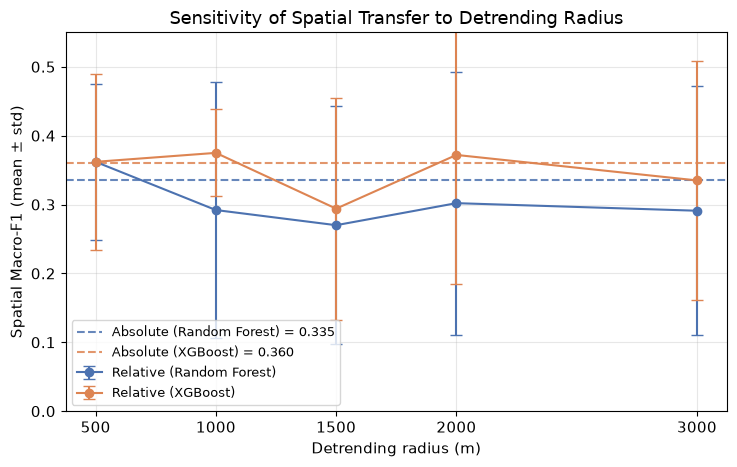


Saved sensitivity_results.csv and Fig_sensitivity_radius.png


In [174]:
# 5. Figure 3: Sensitivity of Spatial Transfer to Detrending Radius (500, 1.000, 1.500, 2.000, 3.000 m).
RANDOM_STATE, DPI = 42, 300
plt.rcParams.update({"font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

# radius (m) -> CSV file name
RADIUS_CSV = {
    500:  'assets/rw_ciliwung_sens_r500.csv',
    1000: 'assets/rw_ciliwung_sens_r1000.csv',
    1500: 'assets/rw_ciliwung_sens_r1500.csv',
    2000: 'assets/rw_ciliwung_sens_r2000.csv',
    3000: 'assets/rw_ciliwung_sens_r3000.csv',
}


LABEL_MAP = {"Sangat Rendah":0,"Rendah":0,"Sedang":1,"Tinggi":2,"Sangat Tinggi":2}
ABS = ["elevation_mean","elevation_min","hand_mean","hand_min","twi_mean",
       "dist_river_min","slope_mean","upstream_area_max","builtup_mean",
       "vegetasi_mean","VV_dry_mean","VH_dry_mean"]
REL = ["elevation_rel_mean","elevation_rel_min","hand_rel_mean","hand_rel_min",
       "twi_rel_mean","dist_river_rel_min","slope_rel_mean","upstream_area_rel_max",
       "builtup_mean","vegetasi_mean","VV_dry_mean","VH_dry_mean"]
COMB = ["elevation_mean","elevation_min","elevation_rel_mean","elevation_rel_min",
        "hand_mean","hand_min","hand_rel_mean","hand_rel_min","twi_mean","twi_rel_mean",
        "dist_river_min","dist_river_rel_min","slope_mean","slope_rel_mean",
        "upstream_area_max","upstream_area_rel_max","builtup_mean","vegetasi_mean",
        "VV_dry_mean","VH_dry_mean"]

def make(name):
    if name == "Random Forest":
        return RandomForestClassifier(n_estimators=300, max_depth=None,
                                      min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
    return xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                             subsample=1.0, colsample_bytree=1.0, objective="multi:softmax",
                             num_class=3, eval_metric="mlogloss",
                             random_state=RANDOM_STATE, n_jobs=-1)

def spatial_macro_f1(df, feats):
    d = df[df["Kategori_B"].isin(LABEL_MAP)].copy()
    d["target"] = d["Kategori_B"].map(LABEL_MAP).astype(int)
    X, y, g = d[feats], d["target"], d["WILAYAH"]
    out = {}
    for mn in ["Random Forest", "XGBoost"]:
        f1s = []
        for tr, te in GroupKFold(n_splits=5).split(X, y, g):
            m = make(mn); m.fit(X.iloc[tr], y.iloc[tr])
            f1s.append(f1_score(y.iloc[te], m.predict(X.iloc[te]), average="macro", zero_division=0))
        out[mn] = (float(np.mean(f1s)), float(np.std(f1s)))
    return out

# Absolute baseline (same at any radius)
abs_base = spatial_macro_f1(pd.read_csv(next(iter(RADIUS_CSV.values()))), ABS)
print("Absolute baseline:", {k: f"{v[0]:.3f}+/-{v[1]:.3f}" for k, v in abs_base.items()})

rows = []
for r, path in RADIUS_CSV.items():
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"skip r={r} (not found: {path})"); continue
    for rep, feats in [("Relative", REL), ("Combined", COMB)]:
        res = spatial_macro_f1(df, feats)
        for mn, (mean, std) in res.items():
            rows.append({"Radius_m": r, "Representation": rep, "Model": mn,
                         "MacroF1_mean": round(mean, 3), "MacroF1_std": round(std, 3)})
res_df = pd.DataFrame(rows).sort_values(["Representation", "Model", "Radius_m"])
print("\n=== Sensitivity results ===")
print(res_df.to_string(index=False))
res_df.to_csv("sensitivity_results.csv", index=False)

# plot: Relative vs radius, Absolute as reference lines
radii = sorted(RADIUS_CSV)
fig, ax = plt.subplots(figsize=(7.5, 4.8))
colors = {"Random Forest": "#4C72B0", "XGBoost": "#DD8452"}
for mn in ["Random Forest", "XGBoost"]:
    sub = res_df[(res_df.Representation == "Relative") & (res_df.Model == mn)].sort_values("Radius_m")
    ax.errorbar(sub.Radius_m, sub.MacroF1_mean, yerr=sub.MacroF1_std,
                marker="o", capsize=4, color=colors[mn], label=f"Relative ({mn})")
    ax.axhline(abs_base[mn][0], ls="--", color=colors[mn], alpha=0.85,
               label=f"Absolute ({mn}) = {abs_base[mn][0]:.3f}")
ax.set_xlabel("Detrending radius (m)")
ax.set_ylabel("Spatial Macro-F1 (mean ± std)")
ax.set_title("Sensitivity of Spatial Transfer to Detrending Radius")
ax.set_xticks(radii); ax.set_ylim(0, 0.55); ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig("Fig_sensitivity_radius.png", dpi=DPI); plt.show()
print("\nSaved sensitivity_results.csv and Fig_sensitivity_radius.png")

In [175]:
#6. Table II: Absolute vs Relative vs Combined
results = []
oof_reports = {}

for representation, features in FEATURE_SETS.items():

    X = dilatih[features].copy()
    y = dilatih["target"].copy()

    #Check missing values in the features used
    valid = X.notna().all(axis=1)

    if not valid.all():
        print(
            f"{representation}: dropping "
            f"{(~valid).sum()} rows with missing values."
        )

    X = X.loc[valid]
    y = y.loc[valid]
    groups_valid = groups.loc[valid]

    for model_name, model_template in make_models().items():

        fold_accuracy = []
        fold_macro_f1 = []

        oof_true = []
        oof_pred = []

        for fold, (train_idx, test_idx) in enumerate(
            gkf.split(X, y, groups_valid), start=1
        ):

            model = make_models()[model_name]

            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            acc = accuracy_score(y_test, pred)
            macro = f1_score(
                y_test,
                pred,
                average="macro",
                zero_division=0
            )

            fold_accuracy.append(acc)
            fold_macro_f1.append(macro)

            oof_true.extend(y_test.tolist())
            oof_pred.extend(pred.tolist())

        results.append({
            "Representation": representation,
            "Model": model_name,
            "Spatial_Accuracy_Mean": np.mean(fold_accuracy),
            "Spatial_Accuracy_Std": np.std(fold_accuracy),
            "Spatial_MacroF1_Mean": np.mean(fold_macro_f1),
            "Spatial_MacroF1_Std": np.std(fold_macro_f1)
        })

        #Combine all folds first, then compute metrics
        oof_reports[(representation, model_name)] = {
            "y_true": np.array(oof_true),
            "y_pred": np.array(oof_pred)
        }

results_df = pd.DataFrame(results)

results_df.sort_values(
    "Spatial_MacroF1_Mean",
    ascending=False
)


,Representation,Model,Spatial_Accuracy_Mean,Spatial_Accuracy_Std,Spatial_MacroF1_Mean,Spatial_MacroF1_Std
1,Absolute,XGBoost,0.522985,0.062226,0.359730,0.044265
0,Absolute,Random Forest,0.517328,0.126365,0.335189,0.075437
3,Relative,XGBoost,0.399163,0.212325,0.294373,0.161079
2,Relative,Random Forest,0.400080,0.247800,0.270049,0.172659
5,Combined,XGBoost,0.384333,0.217977,0.267206,0.157381
4,Combined,Random Forest,0.408222,0.244008,0.264336,0.152376


In [176]:
# Per-class performance
class_names = ["Low", "Medium", "High"]

per_class_rows = []

for (representation, model_name), report in oof_reports.items():

    cr = classification_report(
        report["y_true"],
        report["y_pred"],
        labels=[0, 1, 2],
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    for cls in class_names:
        per_class_rows.append({
            "Representation": representation,
            "Model": model_name,
            "Class": cls,
            "Precision": cr[cls]["precision"],
            "Recall": cr[cls]["recall"],
            "F1": cr[cls]["f1-score"]
        })

per_class_df = pd.DataFrame(per_class_rows)

per_class_df


,Representation,Model,Class,Precision,Recall,F1
0,Absolute,Random Forest,Low,0.476190,0.294118,0.363636
1,Absolute,Random Forest,Medium,0.459016,0.451613,0.455285
2,Absolute,Random Forest,High,0.700000,0.813953,0.752688
3,Absolute,XGBoost,Low,0.516129,0.470588,0.492308
4,Absolute,XGBoost,Medium,0.403846,0.338710,0.368421
5,Absolute,XGBoost,High,0.646465,0.744186,0.691892
6,Relative,Random Forest,Low,0.294118,0.147059,0.196078
7,Relative,Random Forest,Medium,0.454545,0.483871,0.468750
8,Relative,Random Forest,High,0.686869,0.790698,0.735135
9,Relative,XGBoost,Low,0.393939,0.382353,0.388060


In [177]:
# Confusion Matrix

for (representation, model_name), report in oof_reports.items():

    cm = confusion_matrix(
        report["y_true"],
        report["y_pred"],
        labels=[0, 1, 2]
    )

    print(f"\n{'='*65}")
    print(f"{representation} — {model_name}")
    print(f"{'='*65}")
    print(pd.DataFrame(
        cm,
        index=["Actual Low", "Actual Medium", "Actual High"],
        columns=["Pred Low", "Pred Medium", "Pred High"]
    ))



Absolute — Random Forest
               Pred Low  Pred Medium  Pred High
Actual Low           10           19          5
Actual Medium         9           28         25
Actual High           2           14         70

Absolute — XGBoost
               Pred Low  Pred Medium  Pred High
Actual Low           16           13          5
Actual Medium        11           21         30
Actual High           4           18         64

Relative — Random Forest
               Pred Low  Pred Medium  Pred High
Actual Low            5           21          8
Actual Medium         9           30         23
Actual High           3           15         68

Relative — XGBoost
               Pred Low  Pred Medium  Pred High
Actual Low           13           16          5
Actual Medium        15           22         25
Actual High           5           20         61

Combined — Random Forest
               Pred Low  Pred Medium  Pred High
Actual Low           10           19          5
Actual Medium     

In [178]:
# Save result

results_df.to_csv(
    "v5_absolute_relative_combined_spatial_groupkfold.csv",
    index=False
)

per_class_df.to_csv(
    "v5_absolute_relative_combined_per_class.csv",
    index=False
)

print("Results saved.")


Results saved.


# **FINAL TEST**

In [179]:
#7. Table III: Baseline vs Class Weighting vs Oversampling
# Validation: Spatial GroupKFold based on GROUP
from sklearn.metrics import precision_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42

#1. Data
ABS_FEATURES = [
    "elevation_mean",
    "elevation_min",
    "hand_mean",
    "hand_min",
    "twi_mean",
    "dist_river_min",
    "slope_mean",
    "upstream_area_max",
    "builtup_mean",
    "vegetasi_mean",
    "VV_dry_mean",
    "VH_dry_mean"
]

TARGET = "target"
GROUP = "WILAYAH"

X = dilatih[ABS_FEATURES].copy()
y = dilatih[TARGET].copy()
groups = dilatih[GROUP].copy()

#Removing all rows with null values
valid = X.notna().all(axis=1)

X = X.loc[valid].reset_index(drop=True)
y = y.loc[valid].reset_index(drop=True)
groups = groups.loc[valid].reset_index(drop=True)

print("Total Data:", len(X))

print("\nClass Distribution:")
print(y.value_counts().sort_index())

print("\nClass Percentage:")
print(
    (y.value_counts(normalize=True).sort_index() * 100).round(2)
)

#2. Spatial GroupKFold
gkf = GroupKFold(n_splits=5)

print("\nTotal Spatial Groups:", groups.nunique())
print("Groups:", sorted(groups.unique()))

#3. Model
def make_rf(class_weight=None):
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


def make_xgb():
    return xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=1.0,
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


#4. Training (3 methods: baseline, class weighting, and oversampling)
methods = [
    "Baseline",
    "Class Weighting",
    "Oversampling"
]

results = []
oof_reports = {}

#5. Run Experiment
for method in methods:

    print("\n" + "=" * 70)
    print("METHOD:", method)
    print("=" * 70)

    for model_name in ["Random Forest", "XGBoost"]:

        fold_accuracy = []
        fold_macro_f1 = []

        oof_true = []
        oof_pred = []

        for fold, (train_idx, test_idx) in enumerate(
            gkf.split(X, y, groups),
            start=1
        ):

            X_train = X.iloc[train_idx].copy()
            X_test = X.iloc[test_idx].copy()

            y_train = y.iloc[train_idx].copy()
            y_test = y.iloc[test_idx].copy()

            #BASELINE
            if method == "Baseline":

                if model_name == "Random Forest":
                    model = make_rf(class_weight=None)

                else:
                    model = make_xgb()

                model.fit(X_train, y_train)

            #CLASS WEIGHTING
            elif method == "Class Weighting":

                if model_name == "Random Forest":

                    model = make_rf(
                        class_weight="balanced"
                    )

                    model.fit(X_train, y_train)

                else:

                    model = make_xgb()

                    sample_weight = compute_sample_weight(
                        class_weight="balanced",
                        y=y_train
                    )

                    model.fit(
                        X_train,
                        y_train,
                        sample_weight=sample_weight
                    )

            #OVERSAMPLING
            elif method == "Oversampling":

                ros = RandomOverSampler(
                    random_state=RANDOM_STATE
                )

                X_train_resampled, y_train_resampled = ros.fit_resample(
                    X_train,
                    y_train
                )

                if model_name == "Random Forest":
                    model = make_rf(class_weight=None)

                else:
                    model = make_xgb()

                model.fit(
                    X_train_resampled,
                    y_train_resampled
                )

            #PREDICTION
            pred = model.predict(X_test)

            acc = accuracy_score(y_test, pred)

            macro_f1 = f1_score(
                y_test,
                pred,
                average="macro",
                zero_division=0
            )

            fold_accuracy.append(acc)
            fold_macro_f1.append(macro_f1)

            oof_true.extend(y_test.tolist())
            oof_pred.extend(pred.tolist())

            print(
                f"Fold {fold}: "
                f"Accuracy={acc:.3f}, "
                f"Macro-F1={macro_f1:.3f}"
            )

        #SAVE RESULT
        results.append({
            "Method": method,
            "Model": model_name,
            "Spatial_Accuracy_Mean": np.mean(fold_accuracy),
            "Spatial_Accuracy_Std": np.std(fold_accuracy),
            "Spatial_MacroF1_Mean": np.mean(fold_macro_f1),
            "Spatial_MacroF1_Std": np.std(fold_macro_f1)
        })

        oof_reports[(method, model_name)] = {
            "y_true": np.array(oof_true),
            "y_pred": np.array(oof_pred)
        }

#6. Result
results_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("RESULTS OF 3 TRAINING METHODS")
print("=" * 80)

display(
    results_df.sort_values(
        "Spatial_MacroF1_Mean",
        ascending=False
    )
)

Total Data: 182

Class Distribution:
target
0    34
1    62
2    86
Name: count, dtype: int64

Class Percentage:
target
0    18.68
1    34.07
2    47.25
Name: proportion, dtype: float64

Total Spatial Groups: 5
Groups: ['JAKARTA BARAT', 'JAKARTA PUSAT', 'JAKARTA SELATAN', 'JAKARTA TIMUR', 'JAKARTA UTARA']

METHOD: Baseline
Fold 1: Accuracy=0.684, Macro-F1=0.437
Fold 2: Accuracy=0.636, Macro-F1=0.396
Fold 3: Accuracy=0.414, Macro-F1=0.283
Fold 4: Accuracy=0.353, Macro-F1=0.227
Fold 5: Accuracy=0.500, Macro-F1=0.333
Fold 1: Accuracy=0.570, Macro-F1=0.353
Fold 2: Accuracy=0.582, Macro-F1=0.430
Fold 3: Accuracy=0.552, Macro-F1=0.382
Fold 4: Accuracy=0.412, Macro-F1=0.300
Fold 5: Accuracy=0.500, Macro-F1=0.333

METHOD: Class Weighting
Fold 1: Accuracy=0.696, Macro-F1=0.438
Fold 2: Accuracy=0.673, Macro-F1=0.416
Fold 3: Accuracy=0.621, Macro-F1=0.443
Fold 4: Accuracy=0.353, Macro-F1=0.227
Fold 5: Accuracy=0.500, Macro-F1=0.333
Fold 1: Accuracy=0.570, Macro-F1=0.353
Fold 2: Accuracy=0.600, Ma

,Method,Model,Spatial_Accuracy_Mean,Spatial_Accuracy_Std,Spatial_MacroF1_Mean,Spatial_MacroF1_Std
4,Oversampling,Random Forest,0.597833,0.094439,0.431881,0.103117
2,Class Weighting,Random Forest,0.568512,0.127321,0.371532,0.082197
5,Oversampling,XGBoost,0.540204,0.105826,0.369383,0.068172
1,Baseline,XGBoost,0.522985,0.062226,0.359730,0.044265
3,Class Weighting,XGBoost,0.521754,0.091147,0.359012,0.067793
0,Baseline,Random Forest,0.517328,0.126365,0.335189,0.075437


In [180]:
#Per-class Performance
class_names = ["Low", "Medium", "High"]

per_class_rows = []

for (method, model_name), report in oof_reports.items():

    cr = classification_report(
        report["y_true"],
        report["y_pred"],
        labels=[0, 1, 2],
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    for cls in class_names:

        per_class_rows.append({
            "Method": method,
            "Model": model_name,
            "Class": cls,
            "Precision": cr[cls]["precision"],
            "Recall": cr[cls]["recall"],
            "F1": cr[cls]["f1-score"]
        })

per_class_df = pd.DataFrame(per_class_rows)

display(per_class_df)

,Method,Model,Class,Precision,Recall,F1
0,Baseline,Random Forest,Low,0.476190,0.294118,0.363636
1,Baseline,Random Forest,Medium,0.459016,0.451613,0.455285
2,Baseline,Random Forest,High,0.700000,0.813953,0.752688
3,Baseline,XGBoost,Low,0.516129,0.470588,0.492308
4,Baseline,XGBoost,Medium,0.403846,0.338710,0.368421
5,Baseline,XGBoost,High,0.646465,0.744186,0.691892
6,Class Weighting,Random Forest,Low,0.592593,0.470588,0.524590
7,Class Weighting,Random Forest,Medium,0.551020,0.435484,0.486486
8,Class Weighting,Random Forest,High,0.698113,0.860465,0.770833
9,Class Weighting,XGBoost,Low,0.515152,0.500000,0.507463


In [181]:
#Confusion Matrix
for (method, model_name), report in oof_reports.items():

    cm = confusion_matrix(
        report["y_true"],
        report["y_pred"],
        labels=[0, 1, 2]
    )

    print("\n" + "=" * 70)
    print(f"{method} — {model_name}")
    print("=" * 70)

    display(
        pd.DataFrame(
            cm,
            index=[
                "Actual Low",
                "Actual Medium",
                "Actual High"
            ],
            columns=[
                "Pred Low",
                "Pred Medium",
                "Pred High"
            ]
        )
    )


Baseline — Random Forest


,Pred Low,Pred Medium,Pred High
Actual Low,10,19,5
Actual Medium,9,28,25
Actual High,2,14,70



Baseline — XGBoost


,Pred Low,Pred Medium,Pred High
Actual Low,16,13,5
Actual Medium,11,21,30
Actual High,4,18,64



Class Weighting — Random Forest


...

,Pred Low,Pred Medium,Pred High
Actual Low,17,12,5
Actual Medium,12,21,29
Actual High,4,18,64



Oversampling — Random Forest


,Pred Low,Pred Medium,Pred High
Actual Low,19,10,5
Actual Medium,12,28,22
Actual High,2,11,73



Oversampling — XGBoost


,Pred Low,Pred Medium,Pred High
Actual Low,18,11,5
Actual Medium,15,23,24
Actual High,3,16,67


In [182]:
# Method Comparison
comparison = results_df[
    [
        "Method",
        "Model",
        "Spatial_MacroF1_Mean",
        "Spatial_MacroF1_Std",
        "Spatial_Accuracy_Mean"
    ]
].copy()

comparison = comparison.sort_values(
    "Spatial_MacroF1_Mean",
    ascending=False
)

display(comparison)

,Method,Model,Spatial_MacroF1_Mean,Spatial_MacroF1_Std,Spatial_Accuracy_Mean
4,Oversampling,Random Forest,0.431881,0.103117,0.597833
2,Class Weighting,Random Forest,0.371532,0.082197,0.568512
5,Oversampling,XGBoost,0.369383,0.068172,0.540204
1,Baseline,XGBoost,0.359730,0.044265,0.522985
3,Class Weighting,XGBoost,0.359012,0.067793,0.521754
0,Baseline,Random Forest,0.335189,0.075437,0.517328


# FINAL REPORT

In [183]:
#8. Final Model Configuration: Absolute, Random Forest, Oversampling
FINAL_METHOD = "Oversampling"
FINAL_MODEL = "Random Forest"

print("Final Model:")
print(f"Feature Representation : Absolute")
print(f"Balancing Method       : {FINAL_METHOD}")
print(f"Model                  : {FINAL_MODEL}")
print(f"Validation             : 5-fold Spatial GroupKFold")

Final Model:
Feature Representation : Absolute
Balancing Method       : Oversampling
Model                  : Random Forest
Validation             : 5-fold Spatial GroupKFold


In [184]:
# Taking Out-of-Fold final model prediction
final_report = oof_reports[(FINAL_METHOD, FINAL_MODEL)]

y_true_final = final_report["y_true"]
y_pred_final = final_report["y_pred"]

print("Number of OOF samples:", len(y_true_final))

Number of OOF samples: 182


In [185]:
# Overall Final Model Metrics (Accuracy, Macro-F1, Kappa, QWK)
from sklearn.metrics import cohen_kappa_score

accuracy_final = accuracy_score(
    y_true_final,
    y_pred_final
)

macro_f1_final = f1_score(
    y_true_final,
    y_pred_final,
    average="macro",
    zero_division=0
)

kappa_final = cohen_kappa_score(
    y_true_final,
    y_pred_final
)

qwk_final = cohen_kappa_score(
    y_true_final,
    y_pred_final,
    weights="quadratic"
)

print("=" * 60)
print("FINAL MODEL — OVERALL PERFORMANCE")
print("=" * 60)

print(f"Spatial Accuracy : {accuracy_final:.3f}")
print(f"Spatial Macro-F1 : {macro_f1_final:.3f}")
print(f"Cohen's Kappa    : {kappa_final:.3f}")
print(f"QWK              : {qwk_final:.3f}")

FINAL MODEL — OVERALL PERFORMANCE
Spatial Accuracy : 0.659
Spatial Macro-F1 : 0.619
Cohen's Kappa    : 0.446
QWK              : 0.613


In [186]:
# Class-Level Final Model F1, Precision, and Recall
class_names = ["Low", "Medium", "High"]

report_final = classification_report(
    y_true_final,
    y_pred_final,
    labels=[0, 1, 2],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class_final = pd.DataFrame({
    "Class": class_names,
    "Precision": [
        report_final["Low"]["precision"],
        report_final["Medium"]["precision"],
        report_final["High"]["precision"]
    ],
    "Recall": [
        report_final["Low"]["recall"],
        report_final["Medium"]["recall"],
        report_final["High"]["recall"]
    ],
    "F1": [
        report_final["Low"]["f1-score"],
        report_final["Medium"]["f1-score"],
        report_final["High"]["f1-score"]
    ]
})

display(per_class_final.round(3))

,Class,Precision,Recall,F1
0,Low,0.576,0.559,0.567
1,Medium,0.571,0.452,0.505
2,High,0.730,0.849,0.785


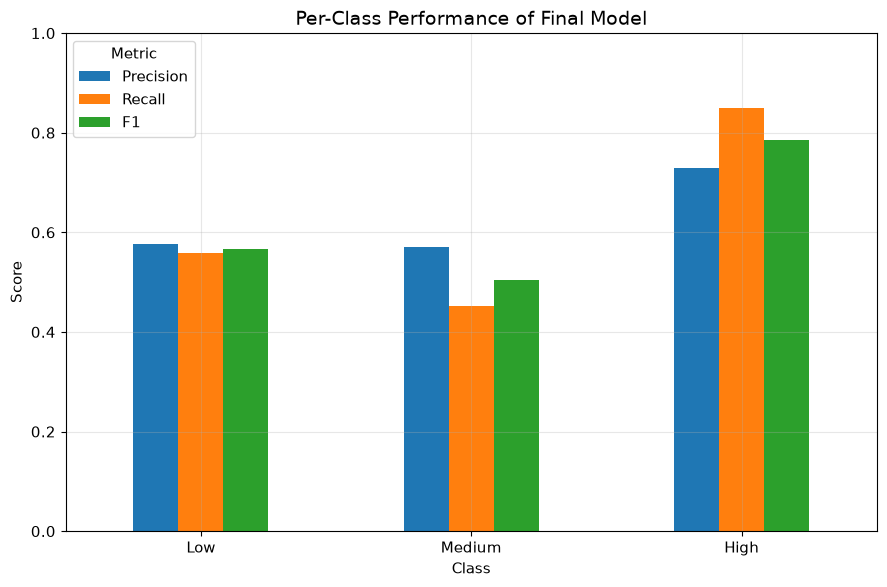

In [187]:
# FIGURE 1 - PER-CLASS PRECISION, RECALL, F1
ax = per_class_final.set_index("Class")[
    ["Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(9, 6)
)

ax.set_title(
    "Per-Class Performance of Final Model",
    fontsize=14
)

ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.legend(title="Metric")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [188]:
# FIGURE 2 — CONFUSION MATRIX
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(
    y_true_final,
    y_pred_final,
    labels=[0, 1, 2]
)

cm_df = pd.DataFrame(
    cm_final,
    index=["Actual Low", "Actual Medium", "Actual High"],
    columns=["Predicted Low", "Predicted Medium", "Predicted High"]
)

display(cm_df)

,Predicted Low,Predicted Medium,Predicted High
Actual Low,19,10,5
Actual Medium,12,28,22
Actual High,2,11,73


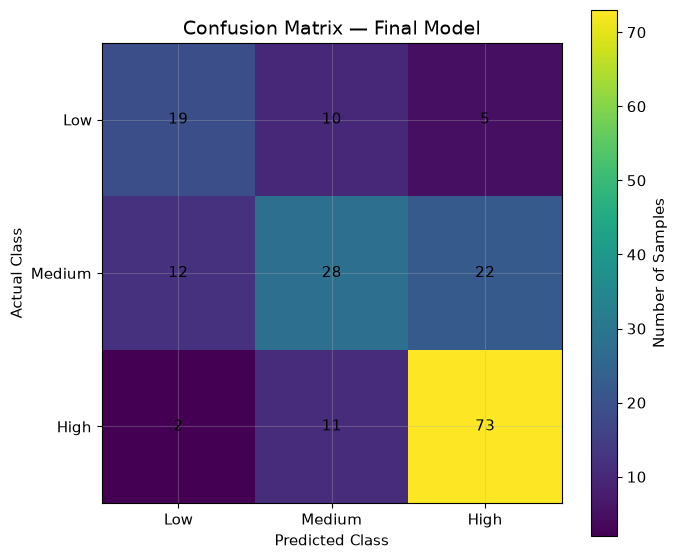

In [189]:
plt.figure(figsize=(7, 6))

plt.imshow(cm_final)

plt.title(
    "Confusion Matrix — Final Model",
    fontsize=14
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1, 2],
    ["Low", "Medium", "High"]
)

plt.yticks(
    [0, 1, 2],
    ["Low", "Medium", "High"]
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm_final[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of Samples")
plt.tight_layout()
plt.show()

In [190]:
# FIGURE 3 — SPATIAL PERFORMANCE PER FOLD
# Final Pipeline: Absolute + RF + Oversampling
fold_results_final = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups),
    start=1
):

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    #Oversampling hanya pada training fold
    ros = RandomOverSampler(
        random_state=RANDOM_STATE
    )

    X_train_resampled, y_train_resampled = ros.fit_resample(
        X_train,
        y_train
    )

    #Final model
    model = make_rf(class_weight=None)

    model.fit(
        X_train_resampled,
        y_train_resampled
    )

    pred = model.predict(X_test)

    fold_acc = accuracy_score(
        y_test,
        pred
    )

    fold_f1 = f1_score(
        y_test,
        pred,
        average="macro",
        zero_division=0
    )

    fold_results_final.append({
        "Fold": fold,
        "Region": groups.iloc[test_idx].iloc[0],
        "Accuracy": fold_acc,
        "Macro-F1": fold_f1
    })

fold_results_final_df = pd.DataFrame(
    fold_results_final
)

display(
    fold_results_final_df.round(3)
)

,Fold,Region,Accuracy,Macro-F1
0,1,JAKARTA TIMUR,0.709,0.454
1,2,JAKARTA SELATAN,0.655,0.409
2,3,JAKARTA BARAT,0.655,0.618
3,4,JAKARTA PUSAT,0.471,0.344
4,5,JAKARTA UTARA,0.500,0.333


In [191]:
# 9. Table IV: Labeled Community Association Data for Random vs Spatial Protocol
from sklearn.model_selection import RepeatedStratifiedKFold

X_rv = dilatih[ABS_FEATURES].reset_index(drop=True)
y_rv = dilatih["target"].reset_index(drop=True)
g_rv = dilatih["WILAYAH"].reset_index(drop=True)
valid_rv = X_rv.notna().all(axis=1)
X_rv = X_rv[valid_rv].reset_index(drop=True)
y_rv = y_rv[valid_rv].reset_index(drop=True)
g_rv = g_rv[valid_rv].reset_index(drop=True)
print("Rows dropped due to missing values:", int((~valid_rv).sum()))
print("RWs used:", len(X_rv))
print(g_rv.value_counts())

Rows dropped due to missing values: 0
RWs used: 182
WILAYAH
JAKARTA TIMUR      79
JAKARTA SELATAN    55
JAKARTA BARAT      29
JAKARTA PUSAT      17
JAKARTA UTARA       2
Name: count, dtype: int64


In [192]:
# TABLE IV [IV-C]: random protocol (5 folds x 10 repeats) and spatial protocol (5 regions).
# Model and Pipeline per Fold
# Random Forest -> 300 trees, min_samples_leaf=2, without class weight, random state=42
# Oversampling -> RandomOverSampler is only applied to the training fold

def make_rf_rv():
    return RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        class_weight=None, random_state=RANDOM_STATE, n_jobs=-1,
    )

def fit_predict_rv(train_idx, test_idx):
    X_res, y_res = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(
        X_rv.iloc[train_idx], y_rv.iloc[train_idx]
    )
    model = make_rf_rv().fit(X_res, y_res)
    return model.predict(X_rv.iloc[test_idx])

# Split Scheme
# Spatial (GroupKFold, 5 Fold) -> each fold consists of one region. The model is trained on the 4 other regions and tested on the held-out region
# Random (RepeatedStratifiedKFold, 5 fold x 10 repeats) -> RWs are randomly split while preserving class proportions, yielding 50 splits

spatial_splits_rv = list(GroupKFold(n_splits=5).split(X_rv, y_rv, g_rv))
random_splits_rv = list(
    RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE).split(X_rv, y_rv)
)
print("Spatial splits:", len(spatial_splits_rv), "| random splits:", len(random_splits_rv))


# in each split, the model is trained then tested
# Fold-Wise: macro f1 and accuracy per fold
# Pooled: out-of-fold predictions from all folds in 1 loop are combined, then macro f1 is computed once
def run_protocol(splits, folds_per_repeat):
    splits = list(splits)
    fold_f1, fold_acc, pooled_f1 = [], [], []
    for start in range(0, len(splits), folds_per_repeat):
        truth_all, pred_all = [], []
        for train_idx, test_idx in splits[start:start + folds_per_repeat]:
            truth = y_rv.iloc[test_idx].to_numpy()
            pred = fit_predict_rv(train_idx, test_idx)
            fold_f1.append(f1_score(truth, pred, average="macro", zero_division=0))
            fold_acc.append(accuracy_score(truth, pred))
            truth_all.extend(truth)
            pred_all.extend(pred)
        pooled_f1.append(f1_score(truth_all, pred_all, average="macro", zero_division=0))
    return np.array(fold_f1), np.array(fold_acc), np.array(pooled_f1)

spatial_f1_rv, spatial_acc_rv, spatial_pooled_rv = run_protocol(spatial_splits_rv, folds_per_repeat=5)
random_f1_rv, random_acc_rv, random_pooled_rv = run_protocol(random_splits_rv, folds_per_repeat=5)

Spatial splits: 5 | random splits: 50


In [193]:
# TABLE IV [IV-C]: random vs spatial table, plus check for absent classes and gap.
def fmt_rv(a):
    return f"{a.mean():.3f} ± {a.std():.3f}" if len(a) > 1 else f"{a.mean():.3f}"

gap_fold_rv = random_f1_rv.mean() - spatial_f1_rv.mean()
gap_pooled_rv = random_pooled_rv.mean() - spatial_pooled_rv.mean()
gap_acc_rv = random_acc_rv.mean() - spatial_acc_rv.mean()

table_iv_rv = pd.DataFrame(
    [
        ["Random (RepeatedStratifiedKFold 5×10)", fmt_rv(random_f1_rv), fmt_rv(random_pooled_rv), fmt_rv(random_acc_rv)],
        ["Spatial (GroupKFold 5 regions)", fmt_rv(spatial_f1_rv), fmt_rv(spatial_pooled_rv), fmt_rv(spatial_acc_rv)],
        ["Gap (Random − Spatial)", f"{gap_fold_rv:.3f}", f"{gap_pooled_rv:.3f}", f"{gap_acc_rv:.3f}"],
    ],
    columns=["Protocol", "Spatial Macro-F1", "Pooled OOF Macro-F1", "Spatial Accuracy"],
)
display(table_iv_rv)

def absent_class_folds_rv(splits):
    return sum(int((np.bincount(y_rv.iloc[te].to_numpy(), minlength=3) == 0).any()) for _, te in splits)

def min_class_counts_rv(splits):
    counts = np.array([np.bincount(y_rv.iloc[te].to_numpy(), minlength=3) for _, te in splits])
    return counts.min(axis=0).tolist()

# print(f"Folds with Absent Class: random {absent_class_folds_rv(random_splits_rv)}/{len(random_splits_rv)}, spatial {absent_class_folds_rv(spatial_splits_rv)}/{len(spatial_splits_rv)}")
# print("Minimum RWs per class (Low, Medium, High) in a single test fold:")
# print("  random :", min_class_counts_rv(random_splits_rv))
# print("  spatial:", min_class_counts_rv(spatial_splits_rv))

spatial_side_rv = spatial_pooled_rv.mean() - spatial_f1_rv.mean()
random_side_rv = random_pooled_rv.mean() - random_f1_rv.mean()
share_rv = (gap_fold_rv - gap_pooled_rv) / gap_fold_rv
print(f"\nFold-wise gap {gap_fold_rv:.3f} - pooled gap {gap_pooled_rv:.3f} = {gap_fold_rv - gap_pooled_rv:.3f} ({share_rv:.0%} of the fold-wise gap)")
print(f"  spatial side (pooled - fold): {spatial_side_rv:.3f}")
print(f"  random side  (pooled - fold): {random_side_rv:.3f}")
print(f"  difference = spatial side - random side = {spatial_side_rv - random_side_rv:.3f}")

spatial_cell12 = results_df.loc[
    (results_df["Method"] == "Oversampling") & (results_df["Model"] == "Random Forest"),
    "Spatial_MacroF1_Mean",
].iloc[0]
print(f"Spatial Macro-F1 (fold-wise) : cell 12 = {spatial_cell12:.3f} | this section = {spatial_f1_rv.mean():.3f}")
print(f"Pooled OOF Macro-F1          : cell 19 = {macro_f1_final:.3f} | this section = {spatial_pooled_rv[0]:.3f}")

,Protocol,Spatial Macro-F1,Pooled OOF Macro-F1,Spatial Accuracy
0,Random (RepeatedStratifiedKFold 5×10),0.662 ± 0.070,0.667 ± 0.013,0.689 ± 0.065
1,Spatial (GroupKFold 5 regions),0.432 ± 0.103,0.619,0.598 ± 0.094
2,Gap (Random − Spatial),0.230,0.048,0.091



Fold-wise gap 0.230 - pooled gap 0.048 = 0.181 (79% of the fold-wise gap)
  spatial side (pooled - fold): 0.187
  random side  (pooled - fold): 0.006
  difference = spatial side - random side = 0.181
Spatial Macro-F1 (fold-wise) : cell 12 = 0.432 | this section = 0.432
Pooled OOF Macro-F1          : cell 19 = 0.619 | this section = 0.619


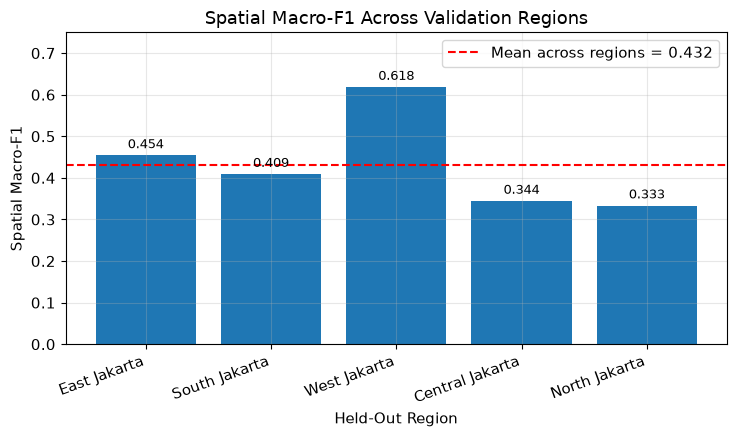

In [194]:
# 10. Figure 5: spatial Macro-F1 per held-out region.
fr = pd.DataFrame(region_rows); mean_f1 = fr["Macro-F1"].mean()
fig, ax = plt.subplots(figsize=(7.5,4.5))
bars = ax.bar(fr["Region"], fr["Macro-F1"])
ax.axhline(mean_f1, linestyle="--", color="red", label=f"Mean across regions = {mean_f1:.3f}")
for b, v in zip(bars, fr["Macro-F1"]):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Spatial Macro-F1"); ax.set_xlabel("Held-Out Region")
ax.set_title("Spatial Macro-F1 Across Validation Regions"); ax.set_ylim(0,0.75)
plt.xticks(rotation=20, ha="right"); ax.legend()
fig.tight_layout(); fig.savefig("Fig6_spatial_regions.png", dpi=DPI); plt.show()

In [195]:
# 11. Validation: Tidal/Subsidence and Jakarta Utara

import re

df11 = df.copy()
print("Number of RWs:", len(df11), "| number of columns:", df11.shape[1])

Number of RWs: 365 | number of columns: 89


In [196]:
# [IV-C] Number of labeled vs unlabeled RWs.
LABEL_MAP_11 = {"Sangat Rendah": 0, "Rendah": 0, "Sedang": 1, "Tinggi": 2, "Sangat Tinggi": 2}
df11["labeled"] = df11["Kategori_B"].isin(LABEL_MAP_11)
df11["target"] = df11["Kategori_B"].map(LABEL_MAP_11)
print("Labeled RWs:", int(df11["labeled"].sum()), "| Unlabeled RWs:", int((~df11["labeled"]).sum()))

Labeled RWs: 182 | Unlabeled RWs: 183


In [197]:
# [IV-C] Check model features: no tidal or subsidence feature exists (basis for 'not included as model features').
PAT_FISIK11 = r"pasang|laut|pesisir|rob|subsid|amblas|tide|coast|sea"
print("CSV columns containing those words:", [c for c in df11.columns if re.search(PAT_FISIK11, c, re.I)])
print("Model features containing those words:", [f for f in ABS_FEATURES if re.search(PAT_FISIK11, f, re.I)])

CSV columns containing those words: []
Model features containing those words: []


In [198]:
# [IV-C] Tidal and subsidence mentions in the data (also used by the prediction cell below).
TIDE11 = r"rob|pasang|laut|pesisir|pasut|tidal"
SUBS11 = r"amblas|penurunan|tanah turun|subsid"
teks11 = (df11["Penyebab_B"].fillna("").astype(str) + " | " + df11["Keterangan"].fillna("").astype(str)).str.lower()
df11["tide_mention"] = teks11.str.contains(TIDE11, regex=True)
df11["subs_mention"] = teks11.str.contains(SUBS11, regex=True)
print("RWs mentioning subsidence:", int(df11["subs_mention"].sum()))
print(pd.crosstab([df11["WILAYAH"], df11["labeled"]], df11["tide_mention"]).to_string())
print("\nExample tidal notes in North Jakarta:")
print(df11.loc[df11["tide_mention"] & (df11["WILAYAH"] == "JAKARTA UTARA"), ["labeled", "Penyebab_B"]].head(10).to_string())

north_lab11 = df11[(df11["WILAYAH"] == "JAKARTA UTARA") & df11["labeled"]]
print(north_lab11[["Kategori_B", "Penyebab_B", "elevation_mean", "dist_river_min"]].to_string())
print("Labeled North RWs mentioning tide:", int(north_lab11["tide_mention"].sum()))

RWs mentioning subsidence: 0
tide_mention             False  True 
WILAYAH         labeled              
JAKARTA BARAT   False        3      0
                True        29      0
JAKARTA PUSAT   False      122      0
                True        15      2
JAKARTA SELATAN False        2      0
                True        55      0
JAKARTA TIMUR   True        79      0
JAKARTA UTARA   False       38     18
                True         2      0

Example tidal notes in North Jakarta:
     labeled                                        Penyebab_B
271    False           Saluran air dangkal dan air laut pasang
272    False  Sungai Tirem meluap, dangkal dan air laut pasang
273    False  Sungai Tirem meluap, dangkal dan air laut pasang
274    False  Sungai Tirem meluap, dangkal dan air laut pasang
275    False           Sungai Tirem meluap dan air laut pasang
276    False           Saluran air dangkal dan air laut pasang
279    False            curah hujan tinggi dan air laut pasang
280    Fal

In [199]:
# [IV-C] Labeled RW coverage per region (Central 12.2%, North 2 labeled RWs).
cov11 = df11.groupby("WILAYAH").agg(total=("labeled", "size"), labeled_count=("labeled", "sum"))
cov11["unlabeled_count"] = cov11["total"] - cov11["labeled_count"]
cov11["percent_labeled"] = (100 * cov11["labeled_count"] / cov11["total"]).round(1)
print(cov11.to_string())

                 total  labeled_count  unlabeled_count  percent_labeled
WILAYAH                                                                
JAKARTA BARAT       32             29                3             90.6
JAKARTA PUSAT      139             17              122             12.2
JAKARTA SELATAN     57             55                2             96.5
JAKARTA TIMUR       79             79                0            100.0
JAKARTA UTARA       58              2               56              3.4


In [200]:
# 12. Figure 6: Predicting 183 Unlabeled Community Association
# Text results: 127 Low, 41 Medium, 15 High; 14 of 15 High in Central Jakarta; 45 of 56 North Jakarta RWs Low.
X_all11 = df11.loc[df11["labeled"], ABS_FEATURES]
y_all11 = df11.loc[df11["labeled"], "target"].astype(int)
X_res11, y_res11 = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(X_all11, y_all11)
rf11 = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight=None, random_state=RANDOM_STATE, n_jobs=-1,
).fit(X_res11, y_res11)

unl11 = df11[~df11["labeled"]].copy()
unl11["pred"] = pd.Series(rf11.predict(unl11[ABS_FEATURES]), index=unl11.index).map({0: "Low", 1: "Medium", 2: "High"})
total11 = unl11["pred"].value_counts().reindex(["Low", "Medium", "High"])
print("Total predictions:", {k: int(v) for k, v in total11.items()})
print(pd.crosstab(unl11["WILAYAH"], unl11["pred"]).reindex(columns=["Low", "Medium", "High"], fill_value=0).to_string())
print("\nRWs predicted High, per region:", unl11.loc[unl11["pred"] == "High", "WILAYAH"].value_counts().to_dict())

n_unl11 = unl11[unl11["WILAYAH"] == "JAKARTA UTARA"]
print("\nUnlabeled North Jakarta, split by tidal mention:")
print(n_unl11.groupby("tide_mention").agg(
    count=("pred", "size"),
    median_elevation=("elevation_mean", "median"),
    Low=("pred", lambda s: int((s == "Low").sum())),
    Medium=("pred", lambda s: int((s == "Medium").sum())),
    High=("pred", lambda s: int((s == "High").sum())),
).rename(index={False: "no tidal mention", True: "has tidal mention"}).round(2).to_string())

Total predictions: {'Low': 127, 'Medium': 41, 'High': 15}
pred             Low  Medium  High
WILAYAH                           
JAKARTA BARAT      3       0     0
JAKARTA PUSAT     79      29    14
JAKARTA SELATAN    0       1     1
JAKARTA UTARA     45      11     0

RWs predicted High, per region: {'JAKARTA PUSAT': 14, 'JAKARTA SELATAN': 1}

Unlabeled North Jakarta, split by tidal mention:
                   count  median_elevation  Low  Medium  High
tide_mention                                                 
no tidal mention      38              4.12   33       5     0
has tidal mention     18              3.03   12       6     0


Predicted unlabeled: {0: np.int64(127), 1: np.int64(41), 2: np.int64(15)}


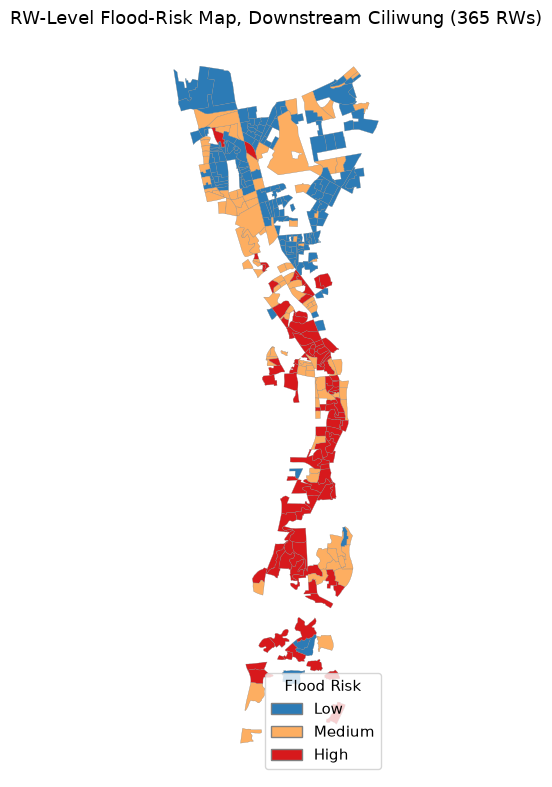

In [201]:
# Flood Risk Mapping from Labeled 182 and Predicted label in 183 Community Associations.
import geopandas as gpd
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

GEOJSON_PATH = "assets/rw_ciliwung_hilir_v5_relatif_geom.geojson"
CLASSES = ["Low", "Medium", "High"]
DPI = 300

gdf = gpd.read_file(GEOJSON_PATH)
gdf["target"] = gdf["Kategori_B"].map(LABEL_MAP)
train = gdf[gdf["target"].notna()]
Xr, yr = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(
    train[ABS], train["target"].astype(int))
rf_final = make_rf().fit(Xr, yr)
gdf["final"] = gdf["target"].fillna(
    pd.Series(rf_final.predict(gdf[ABS]), index=gdf.index)).astype(int)
print("Predicted unlabeled:", dict(pd.Series(
    rf_final.predict(gdf.loc[gdf.target.isna(), ABS])).value_counts().sort_index()))

colors = ["#2c7bb6", "#fdae61", "#d7191c"]  # Low, Medium, High
fig, ax = plt.subplots(figsize=(7,8))
gdf.plot(column="final", categorical=True, cmap=ListedColormap(colors),
         linewidth=0.2, edgecolor="grey", ax=ax)
ax.set_title("RW-Level Flood-Risk Map, Downstream Ciliwung (365 RWs)", fontsize=13)
ax.axis("off")
ax.legend(handles=[Patch(facecolor=colors[i], edgecolor="grey", label=CLASSES[i]) for i in range(3)],
          title="Flood Risk", loc="lower right", frameon=True)
fig.tight_layout(); fig.savefig("Fig7_flood_risk_map.png", dpi=DPI); plt.show()